<a href="https://colab.research.google.com/github/Phoebe-NPA/Data-Analysis/blob/main/Lesson01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
x = np.linspace(0, 10, 500)
y = np.cumsum(np.random.randn(500, 6), 0)

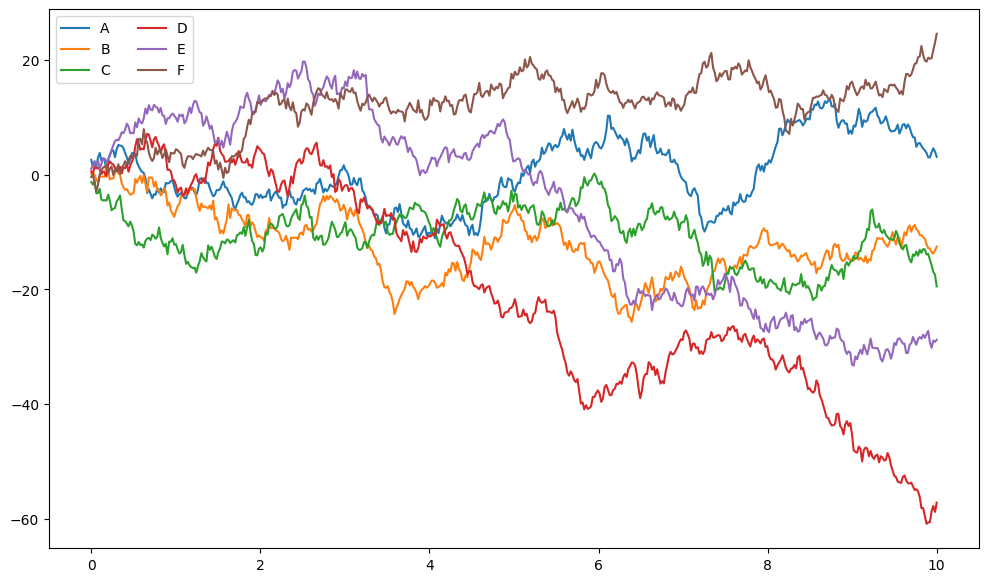

In [6]:
plt.figure(figsize=(12, 7))
plt.plot(x, y)
plt.legend('ABCDEF', ncol=2, loc='upper left')

In [3]:
!git clone https://github.com/Phoebe-NPA/Data-Analysis.git

Cloning into 'Data-Analysis'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 38 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 1.14 MiB | 2.49 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [4]:
%cd Data-Analysis

/content/Data-Analysis


In [5]:
!ls data

sales_data.csv


In [7]:
sales = pd.read_csv('data/sales_data.csv')
sales.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


In [7]:
import requests
import pandas as pd

In [8]:
def get_historic_price(symbol, after='2018-09-01'):

    url = 'https://api.kraken.com/0/public/OHLC'
    pair = f"{symbol.upper()}USD" # XBTUSD when symbol='xbt' for example

    resp = requests.get(url, params={
        "pair": pair,
        'interval': 60,
        'since': str(int(pd.Timestamp(after).timestamp()))
    })
    resp.raise_for_status()

    data = resp.json()

    results_key = [k for k in data['result'].keys() if k != 'last'][0]
    results = [
        (close_time, float(open), float(high), float(low), float(close), float(volume))
        for (close_time, open, high, low, close, vwap, volume, count)
        in data['result'][results_key]
    ]
    df = pd.DataFrame(results, columns=[
        'CloseTime', 'OpenPrice', 'HighPrice', 'LowPrice', 'ClosePrice', 'Volume'
    ])
    df['CloseTime'] = pd.to_datetime(df['CloseTime'], unit='s')
    df.set_index('CloseTime', inplace=True)
    return df

In [9]:
last_week = (pd.Timestamp.now() - pd.offsets.Day(7))
last_week

Timestamp('2026-06-14 16:34:46.946465')

In [10]:
btc = get_historic_price('btc', after=last_week)
eth = get_historic_price('eth', after=last_week)

In [12]:
btc.head()

,OpenPrice,HighPrice,LowPrice,ClosePrice,Volume
CloseTime,,,,,
2026-06-14 17:00:00,63915.4,63988.2,63665.0,63702.2,46.879833
2026-06-14 18:00:00,63702.3,63782.2,63643.3,63777.3,42.569520
2026-06-14 19:00:00,63777.3,63816.8,63712.0,63750.0,62.079767
2026-06-14 20:00:00,63750.0,64077.7,63749.9,63975.3,31.306469
2026-06-14 21:00:00,63975.3,65632.9,63975.3,65273.3,413.114279


In [ ]:
from google.colab import files

uploaded = files.upload()